Data Science Packages

Note

In this exercise, you will practice applying descriptive statistics and data visualization techniques to a real-world dataset. The goal is to strengthen your understanding of the methods learned today and prepare for upcoming assignments on hypothesis testing and machine learning.

You may select a dataset from the options below (at least one is required). Consider reusing the same dataset for later assignments to build continuity in your analysis. The UC Irvine Machine Learning Repository is an excellent resource for additional datasets if you’d like to explore further.
Suggested Datasets

    Palmer Penguins: UC Irvine Machine Learning Repository | R package | CSV export
    Wine Quality Dataset: UC Irvine Machine Learning Repository
    Adult Income Dataset: UC Irvine Machine Learning Repository
    Heart Disease Dataset: UC Irvine Machine Learning Repository
    Car Evaluation Dataset: UC Irvine Machine Learning Repository

Important

Please implement your solutions in a Jupyter notebook called analysis.ipynb and commit it to your repository.

In [2]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd

# Code used from the link shown below
# Link adult dataset - https://archive.ics.uci.edu/dataset/2/adult

# fetch dataset 
adult = fetch_ucirepo(id=2) 

# data (as pandas dataframes) 
x = adult.data.features 
y = adult.data.targets 

# metadata 
print(adult.metadata) 

# variable information 
print(adult.variables) 

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [3]:
# Create a Datamframe from the existing Data
df = pd.concat([x, y], axis=1)
# First look at the df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [4]:
# Quick look at the values and columns
df.head() #fnlwgt

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Visualizing the amount of missing Data
# df.isnull().sum() -> total value
df.isnull().mean() * 100 # Percentage 


age               0.000000
workclass         1.971664
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        1.977806
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    0.560993
income            0.000000
dtype: float64

In [6]:
# Dropping missing Data // Not sure if I should / could also replace them with for example averages here so I ust drop them
df = df.dropna()
df.isnull().sum() 

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [7]:
df.describe()
# count -> Anzahl
# mean -> Mittelwert
# std -> Standardabweichung
# min -> Minimum
# 25 / 50 / 75 -> Quantile (Median)
# max -> Maximum

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,47621.000000,4.762100e+04,47621.000000,47621.000000,47621.000000,47621.000000
mean,38.640684,1.897271e+05,10.090821,1091.137649,87.853489,40.600050
std,13.558961,1.055695e+05,2.568320,7487.228336,404.010612,12.260345
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175840e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.782820e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.377200e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
# Grouping income to age and worked hours
df.groupby('income')[['age', 'hours-per-week']].mean()


,age,hours-per-week
income,,
<=50K,36.783738,38.840210
<=50K.,37.031338,39.418750
>50K,44.249841,45.473026
>50K.,44.101351,45.657838


In [9]:
# Education levels
df["education"].value_counts()

education
HS-grad         15444
Some-college    10512
Bachelors        7881
Masters          2610
Assoc-voc        2034
11th             1746
Assoc-acdm       1566
10th             1336
7th-8th           912
Prof-school       819
9th               735
12th              633
Doctorate         582
5th-6th           494
1st-4th           239
Preschool          78
Name: count, dtype: int64

In [10]:
# Income distribution
df["income"].value_counts(normalize = True) * 100 # Percentage based
# df["income"].value_counts() - total

income
<=50K     51.909872
<=50K.    23.855022
>50K      16.465425
>50K.      7.769681
Name: proportion, dtype: float64

In [11]:
from scipy.stats import skew, kurtosis
# Skewness and Kurtosis

skew_kurt_columns = ["age", "hours-per-week", "capital-gain", "capital-loss"]

print("Skewness:")
print(df[skew_kurt_columns].apply(skew))

print("\nKurtosis:")
print(df[skew_kurt_columns].apply(kurtosis))


Skewness:
age                0.551522
hours-per-week     0.265996
capital-gain      11.828196
capital-loss       4.562979
dtype: float64

Kurtosis:
age                -0.170629
hours-per-week      3.024166
capital-gain      151.048735
capital-loss       19.954480
dtype: float64


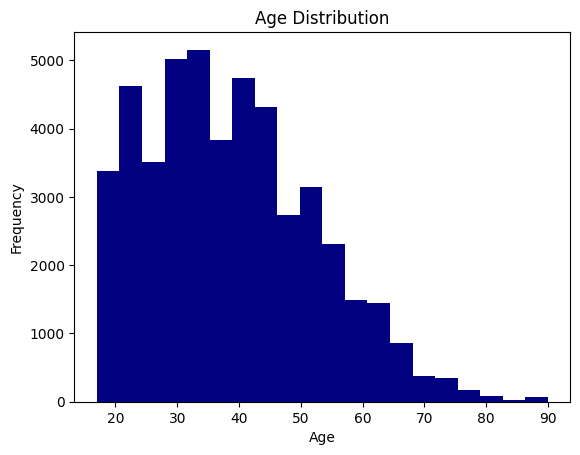

In [12]:
import matplotlib.pyplot as plt
# Age Histogram
df["age"].plot(kind = "hist",
               bins = 20,
               title = "Age Distribution",
               color = "navy")
plt.xlabel("Age")
plt.show()

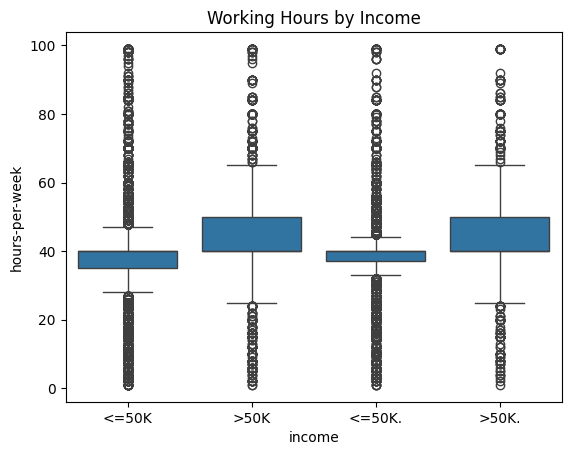

In [13]:
import seaborn as sns
# Boxplot with Income and "Hours per week" worked

sns.boxplot(x="income", y="hours-per-week", data=df)
plt.title("Working Hours by Income")
plt.show()


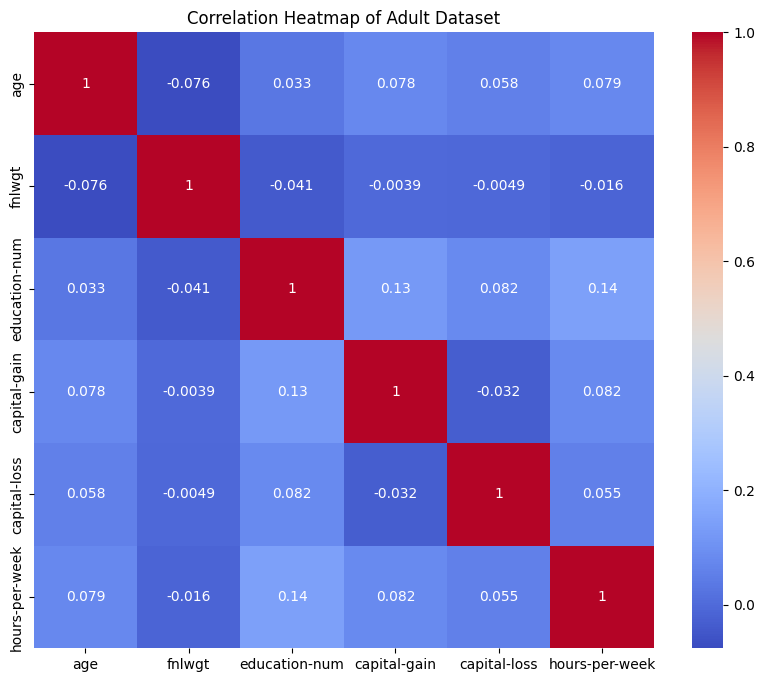

In [14]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Adult Dataset')
plt.show()

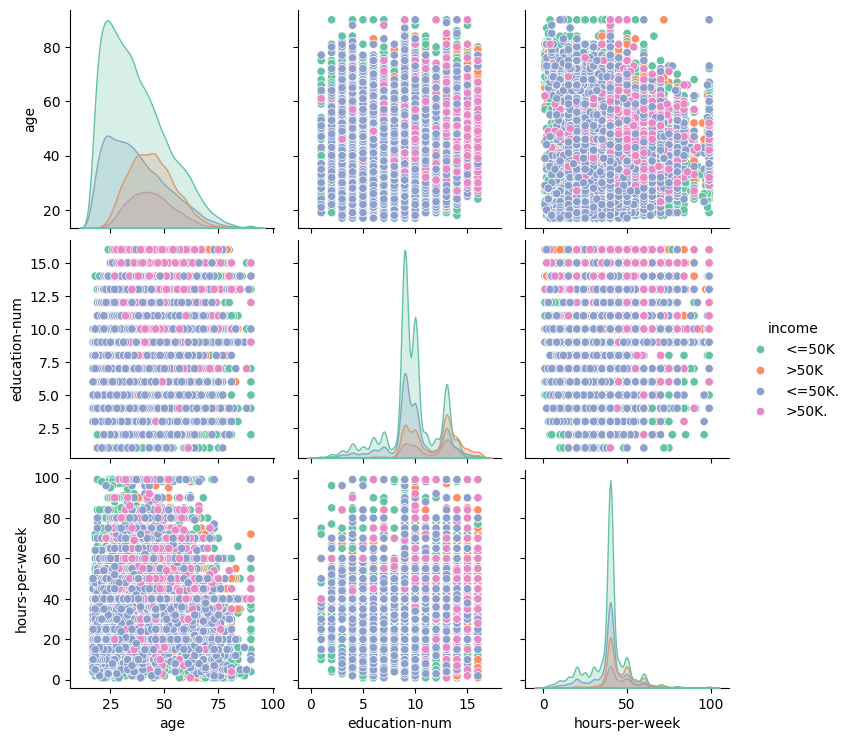

In [ ]:
# Pairwise Relationship
sns.pairplot(
    df[["age", "education-num", "hours-per-week", "income"]],
    hue = "income", palette="Set2"
)
plt.show()

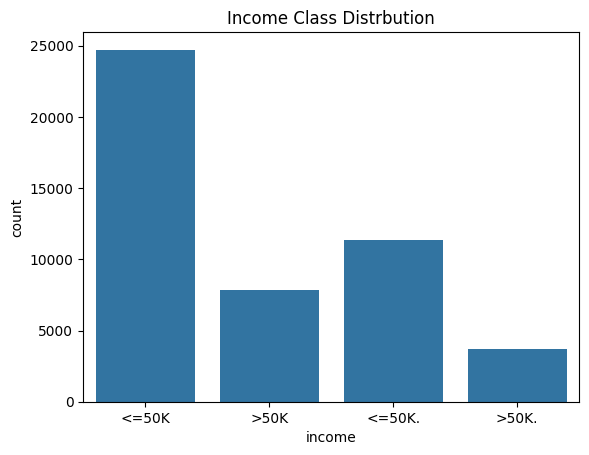

In [ ]:
# Bar Plot for Counts
sns.countplot(x="income", data=df)
plt.title("Income Class Distrbution")
plt.show()

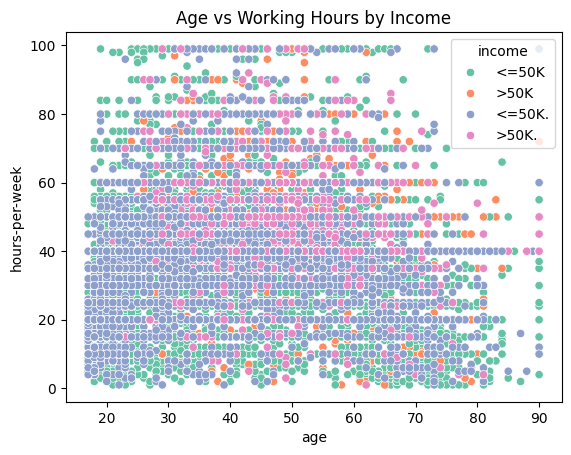

In [19]:
# Scatter Plot
sns.scatterplot(
    data=df,
    x="age",
    y="hours-per-week",
    hue="income",
    palette="Set2"
)
plt.title("Age vs Working Hours by Income")
plt.show()

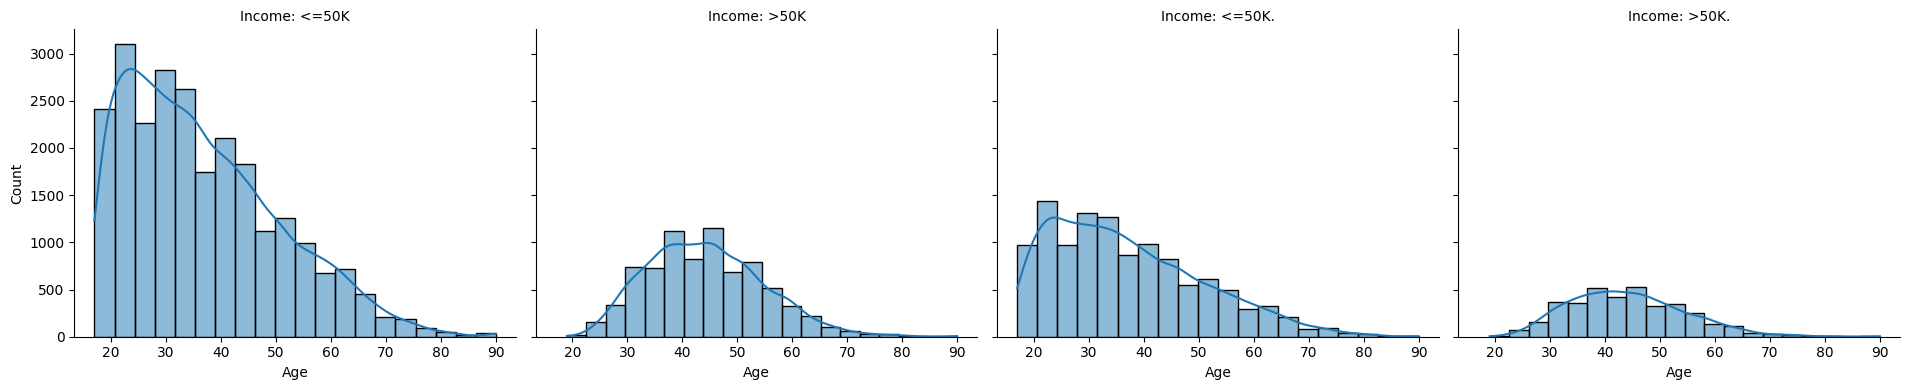

In [ ]:
# FacetGrid for Income
g = sns.FacetGrid(df, col='income', height=4, aspect=1.2)
g.map(sns.histplot, 'age', bins=20, kde=True)
g.set_titles('Income: {col_name}')
g.set_axis_labels('Age', 'Count')
plt.show()


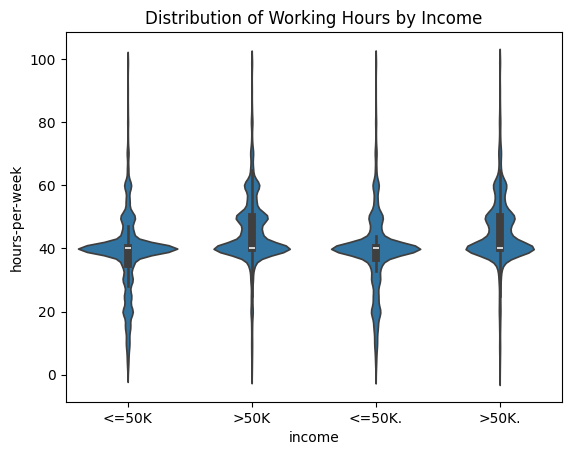

In [21]:
# Violin Plot for distributiion 
sns.violinplot(x='income', y='hours-per-week', data=df)
plt.title('Distribution of Working Hours by Income')
plt.show()


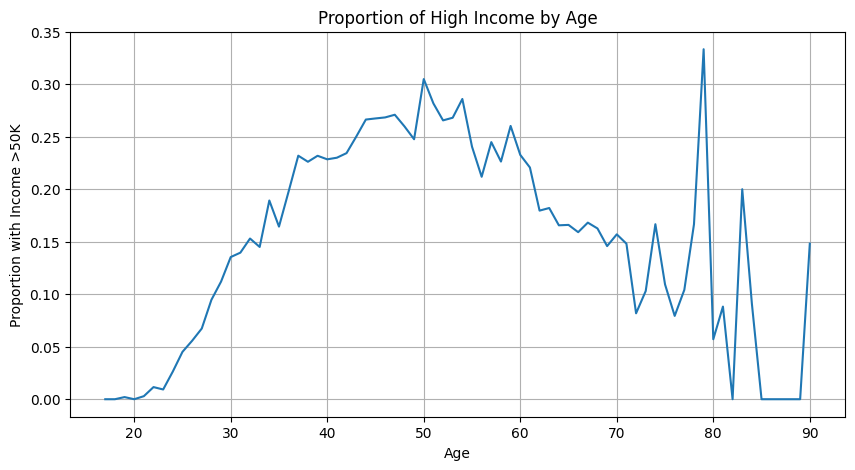

In [24]:
# Line plot for trends
income_rate_by_age = (
    df.assign(high_income=df['income'] == '>50K')
        .groupby('age')['high_income']
        .mean()
)

income_rate_by_age.plot(kind='line', figsize=(10, 5))
plt.title('Proportion of High Income by Age')
plt.xlabel('Age')
plt.ylabel('Proportion with Income >50K')
plt.grid()
plt.show()
